# DEseq2 analysis for ARX, LMO1 dKD

## Loading packages

In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

# Needed for some plotting
import matplotlib.pyplot as plt

# Plotting options, change to your liking
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))

## Loading the data

In [119]:
import scanpy as sc
import pandas as pd
import os
adata = sc.read('/wynton/group/pollen/jding/brainchromatin/Li/LMO1_IN_query.h5ad')
adata.obs['perturbation'] = ['NT' if x=='non-targeting' else 'Perturbed' for x in adata.obs['gene_NKS'] ]
adata.obs['gene_NKS'] = ['ARX,LMO1' if x=='ARX,LMO1,NT' else x for x in adata.obs['gene_NKS'] ]
adata.obs['gene_NKS'] = ['ARX' if x=='ARX,NT' else x for x in adata.obs['gene_NKS'] ]
adata = adata[adata.obs['species'] != 'macaque']
targets = ['LMO1',  'ARX', 'ARX,LMO1', 'non-targeting']
adata.obs['Gene_target'] = adata.obs['gene_NKS'] 
adata = adata[adata.obs['Gene_target'].isin(targets)]
print(targets)

/scratch/jding/ipykernel_628569/1107552677.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Gene_target'] = adata.obs['gene_NKS']


['LMO1', 'ARX', 'ARX,LMO1', 'non-targeting']


In [120]:
adata.obs['sgRNA_effective'] = [','.join(list(set(i for i in x.split(',') if not i.lower().startswith('non-targeting')))) for x in adata.obs['sgRNA'].astype(str)]
adata.obs['sgRNA_effective'] = ['non-targeting' if x == '' else x for x in adata.obs['sgRNA_effective']]
adata.obs['num_sgRNA_effective'] = [len(list(set(x.split(',')))) for x in adata.obs['sgRNA_effective'].astype(str)]
#adata = adata[adata.obs['num_sgRNA_effective'].isin([1,2])]

/scratch/jding/ipykernel_628569/1099549670.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sgRNA_effective'] = [','.join(list(set(i for i in x.split(',') if not i.lower().startswith('non-targeting')))) for x in adata.obs['sgRNA'].astype(str)]


In [122]:
#adata.obs['supervised_name'] = adata.obs['predictions']
adata.obs['KD'] = ['dKD' if x == 'ARX,LMO1' else 'sKD' if x == 'ARX' else 'NA' for x in adata.obs['gene_NKS']]

## Processing

In [124]:
# Store raw counts in layers
#adata.X = np.round(adata.X)
adata.raw = adata.copy()
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
#adata.layers['normalized'] = adata.X

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


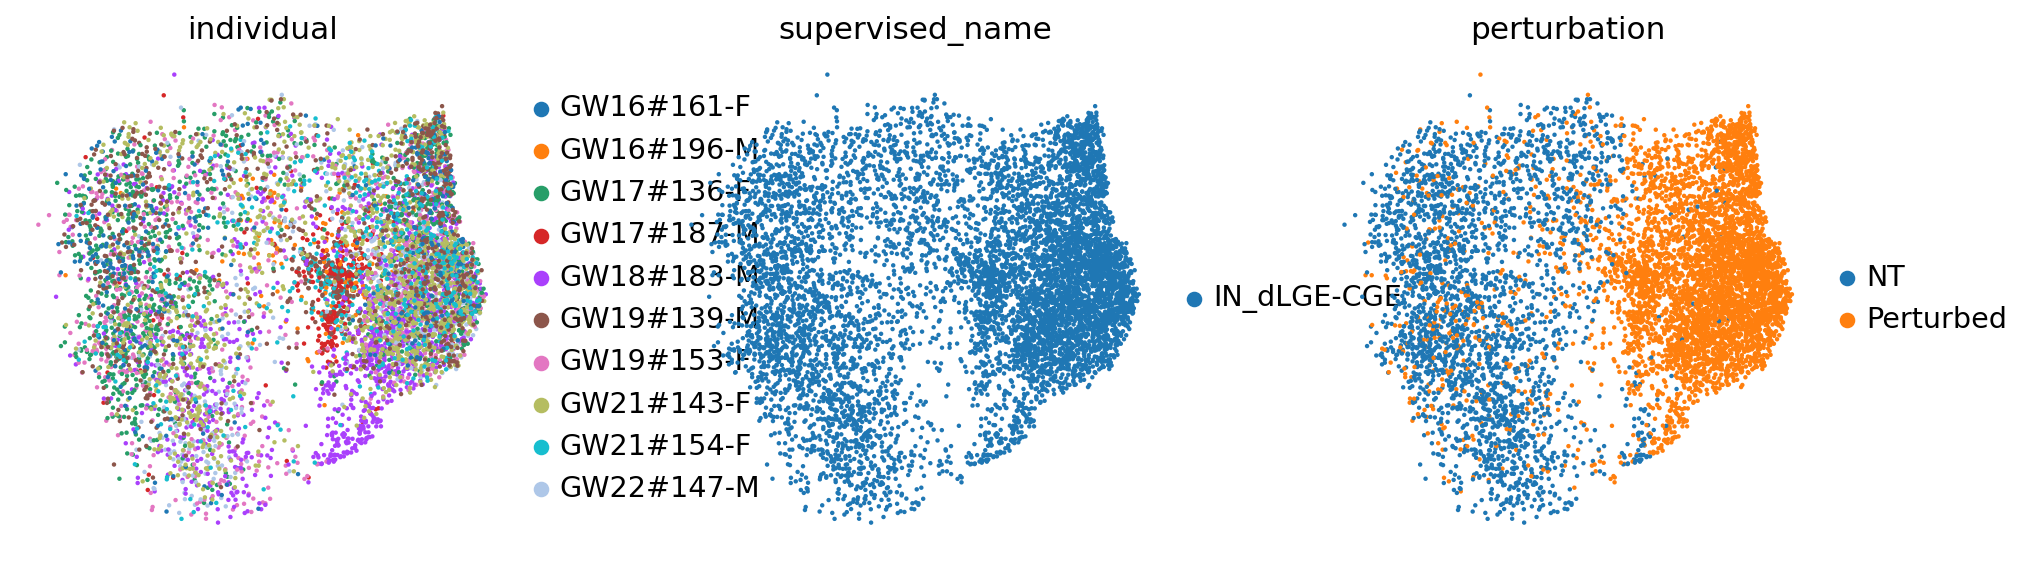

In [125]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, batch_key='individual',min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)

# Visualize
sc.pl.umap(adata, color=['individual','supervised_name','perturbation'], frameon=False)

## Generation of pseudo-bulk profiles

In [126]:
adata.obs['individual-Gene_target'] = adata.obs['individual'].astype(str) + adata.obs['Gene_target'].astype(str)

In [128]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata,
    sample_col='individual-Gene_target',
    groups_col='supervised_name',
    layer='counts',
    mode='sum',
    min_cells=10,
    min_counts=0
)

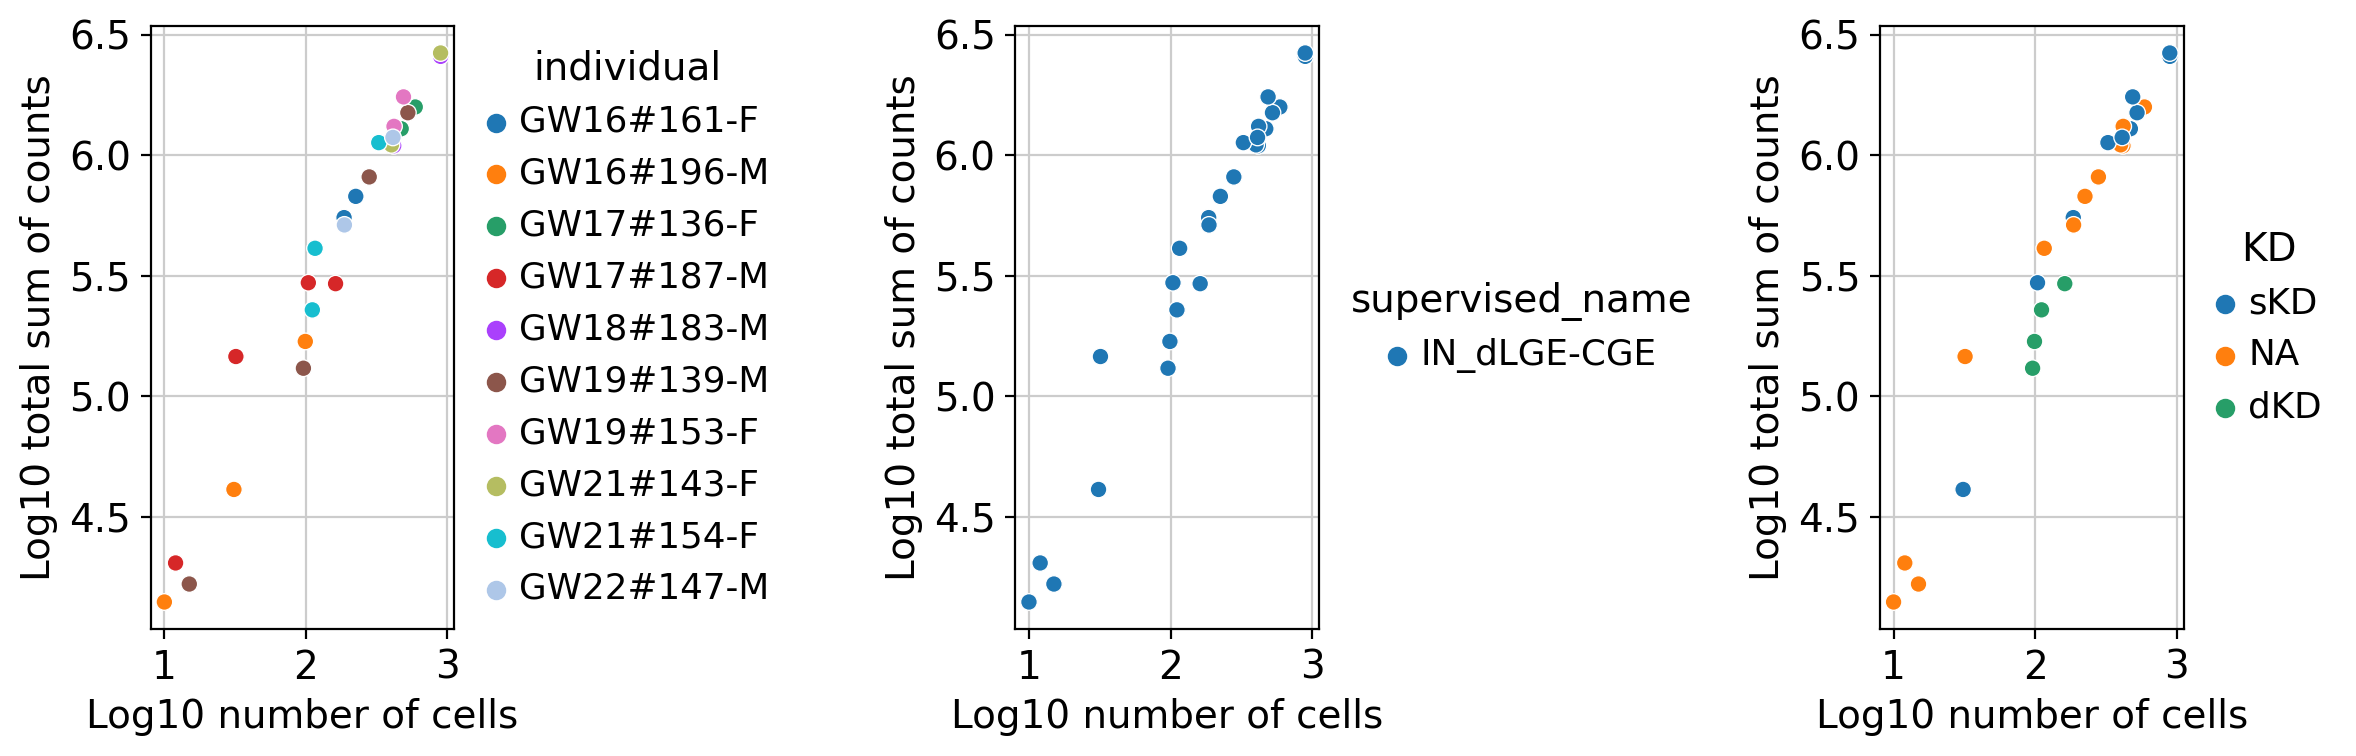

In [129]:
dc.plot_psbulk_samples(pdata, groupby=['individual', 'supervised_name','KD'], figsize=(12, 4))

### Exploration of pseudobulk profiles

In [130]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


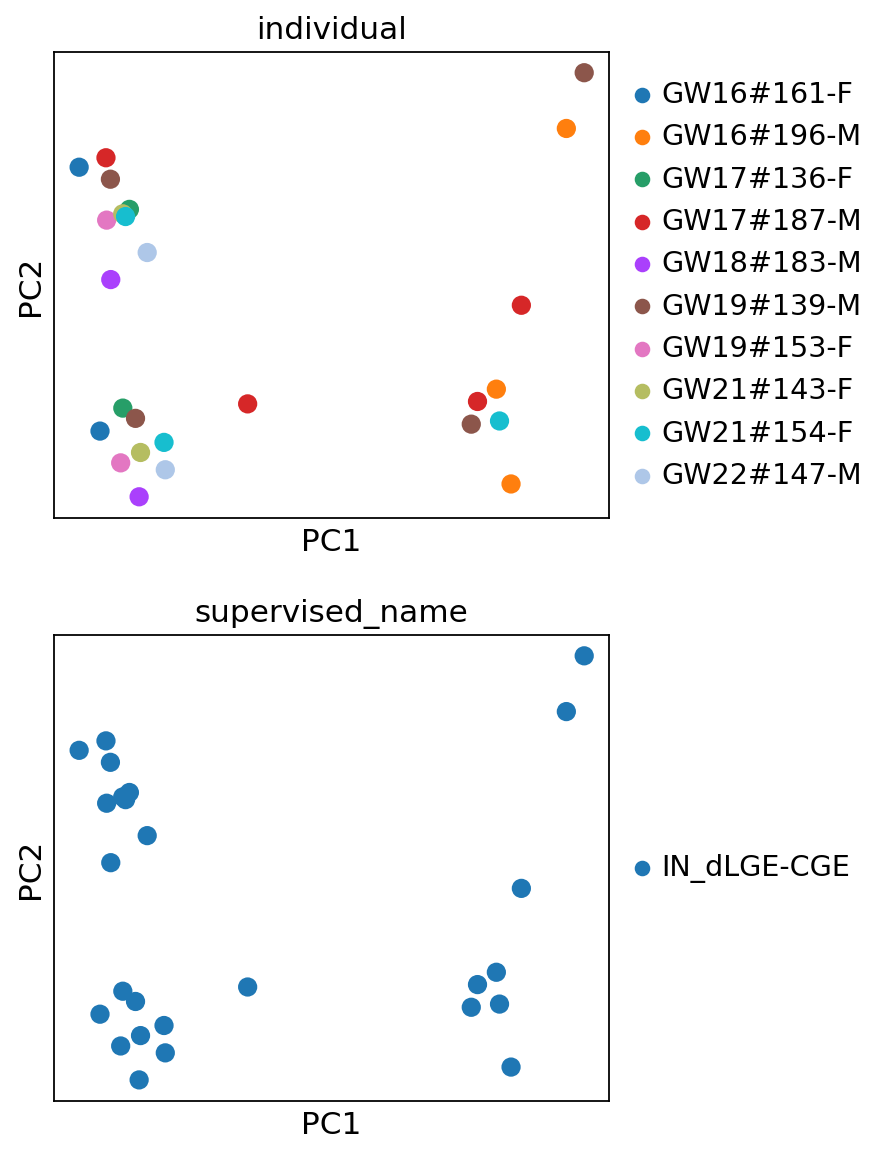

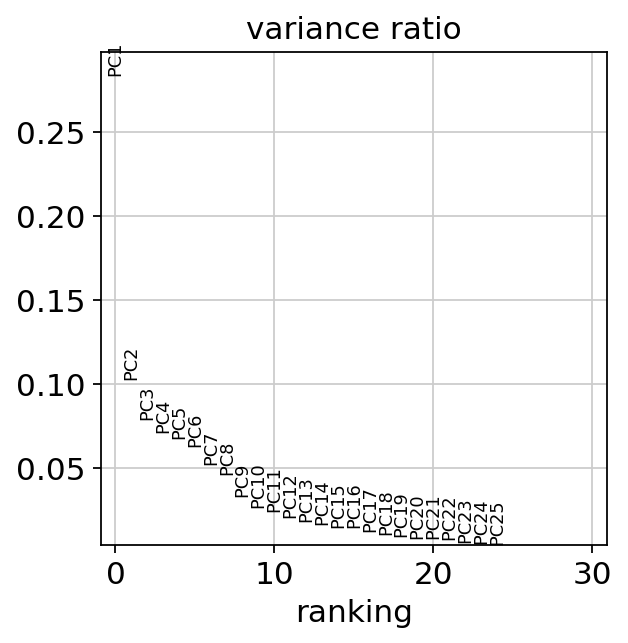

In [131]:
sc.pl.pca(pdata, color=['individual', 'supervised_name'], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

### Pseudo-bulk profile gene filtering

In [135]:
# Obtain genes that pass the thresholds
genes = dc.filter_by_expr(pdata, group='supervised_name', min_count=10, min_total_count=15)

# Filter by these genes
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 26 × 5395
    obs: 'gene_NKS', 'individual', 'stage', 'sex', 'labels_scanvi', 'perturbation', 'supervised_name', 'Gene_target', 'class', 'KD', 'individual-Gene_target', 'psbulk_n_cells', 'psbulk_counts'
    var: 'feature_types-HM2ndD7-HM2D', 'mt-HM2ndD7-HM2D', 'n_cells_by_counts-HM2ndD7-HM2D', 'mean_counts-HM2ndD7-HM2D', 'pct_dropout_by_counts-HM2ndD7-HM2D', 'total_counts-HM2ndD7-HM2D', 'gene_ids-HM2ndD7-HM2D', 'genome-HM2ndD7-HM2D', 'feature_types-HM3rdD7-HM2D', 'gene_ids-0-HM3rdD7-HM2D', 'genome-0-HM3rdD7-HM2D', 'gene_ids-1-HM3rdD7-HM2D', 'genome-1-HM3rdD7-HM2D', 'mt-HM3rdD7-HM2D', 'n_cells_by_counts-HM3rdD7-HM2D', 'mean_counts-HM3rdD7-HM2D', 'pct_dropout_by_counts-HM3rdD7-HM2D', 'total_counts-HM3rdD7-HM2D', 'feature_types-HMD7-HM2D', 'gene_ids-0-HMD7-HM2D', 'genome-0-HMD7-HM2D', 'gene_ids-1-HMD7-HM2D', 'genome-1-HMD7-HM2D', 'mt-HMD7-HM2D', 'n_cells_by_counts-HMD7-HM2D', 'mean_counts-HMD7-HM2D', 'pct_dropout_by_counts-HMD7-HM2D', 'total_counts-HMD

## Contrast between conditions

In [136]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [137]:
dir='/wynton/group/pollen/jding/brainchromatin/HM2D/DEseq2/LMO1'
if not os.path.exists(os.path.join(dir)):
    os.makedirs(os.path.join(dir))
    
inference = DefaultInference(n_cpus=1)
sub = pdata[pdata.obs['KD'] != 'NA']
try:
    dds = DeseqDataSet(adata= sub, design_factors='KD',ref_level=['KD', 'sKD'],
                                       refit_cooks=True,inference=inference)
except KeyError:
    dds = DeseqDataSet(adata= sub, design_factors='KD',ref_level=['KD', 'sKD'],
                                   refit_cooks=True,inference=inference)
dds.deseq2()
stat_res = DeseqStats(dds,contrast=["KD", 'dKD', 'sKD'],inference=inference)
stat_res.summary()
stat_res.results_df.to_csv(os.path.join(dir, 'dKD.csv'))

/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/pydeseq2/dds.py:232: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self.obs[self.design_factors] = self.obs[self.design_factors].astype(str)
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/pydeseq2/dds.py:264: ImplicitModificationWarning: Setting element `.obsm['design_matrix']` of view, initializing view as actual.
  self.obsm["design_matrix"] = build_design_matrix(
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 8.08 seconds.

Fitting dispersion trend curve...
/wynton/home/pollenlab/jding/miniconda3/envs/pertpy/lib/python3.9/site-packages/pydeseq2/dds.py:716: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.24 seconds.

Fitting MAP dispersions...
... done in 7.92

Log2 fold change & Wald test p-value: KD dKD vs sKD
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AAK1      101.245459        0.567693  0.199737  2.842201  0.004480  0.009483
AAMDC      25.282664       -0.406810  0.309623 -1.313886  0.188885  0.253996
AARSD1     20.576545        1.373841  0.288240  4.766310  0.000002  0.000010
AASDH      36.372729       -1.176567  0.354004 -3.323596  0.000889  0.002255
AASDHPPT   43.901103        0.263869  0.276386  0.954711  0.339724  0.417307
...              ...             ...       ...       ...       ...       ...
ZSWIM8     26.579094        0.965716  0.292819  3.297996  0.000974  0.002442
ZXDC       39.476339       -0.128544  0.249507 -0.515192  0.606419  0.675817
ZYG11B     60.542928       -0.594949  0.231748 -2.567225  0.010252  0.019795
ZZEF1      30.308440       -0.927143  0.318364 -2.912214  0.003589  0.007785
ZZZ3       46.528755       -0.867995  0.276438 -3.139924  0.001690  0.003974

[5395 rows x 6 columns]